In [6]:
from google.colab import files
uploaded = files.upload()  # choose supermarket_sales.csv when prompted

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("supermarket_sales.csv")
df.head()

Saving supermarket_sales.csv to supermarket_sales (1).csv


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [9]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1QHueItfd_jDnZYFU4I9V9EeDzR3SdiLctxslF3w68aY/edit#gid=0


In [7]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1616ONBb5BCWpCE7bdy41XDV_N1CSGtfl7IDNoQMiE3Y/edit#gid=0


In [19]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M").dt.time

df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.day_name()
df["Hour"] = pd.to_datetime(df["Time"].astype(str), format="%H:%M:%S").dt.hour

print("Nulls after cleaning:", df.isnull().sum().sum())
print("Duplicates after cleaning:", df.duplicated().sum())

print("\nQuantity range:", df["Quantity"].min(), "-", df["Quantity"].max())
print("Rating range:", df["Rating"].min(), "-", df["Rating"].max())
print("Unique branches:", df["Branch"].unique())
print("Unique product lines:", df["Product line"].unique())

df.head()


Nulls after cleaning: 0
Duplicates after cleaning: 0

Quantity range: 1 - 10
Rating range: 4.0 - 10.0
Unique branches: ['A' 'C' 'B']
Unique product lines: ['Health and beauty' 'Electronic accessories' 'Home and lifestyle'
 'Sports and travel' 'Food and beverages' 'Fashion accessories']


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,...,Time,Payment,cogs,gross margin percentage,gross income,Rating,Day,Month,Weekday,Hour
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,5,1,Saturday,13
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,10:29:00,Cash,76.40,4.761905,3.8200,9.6,8,3,Friday,10
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,...,13:23:00,Credit card,324.31,4.761905,16.2155,7.4,3,3,Sunday,13
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,...,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,27,1,Sunday,20
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,...,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,8,2,Friday,10


Total revenue: $322,966.75
Average transaction value: $322.97

Revenue by branch:
 Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64


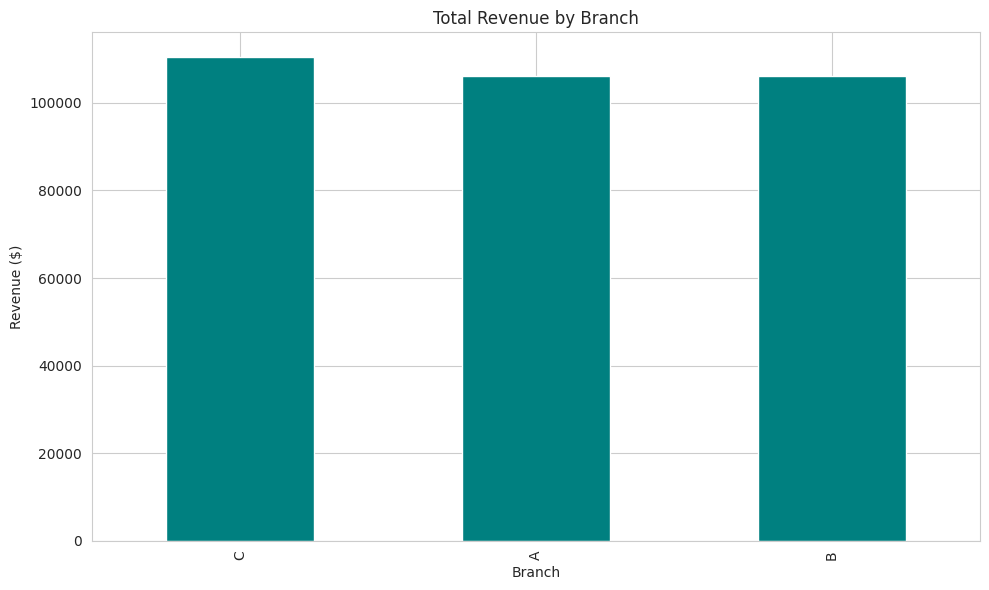

In [10]:
total_revenue = df["Total"].sum()
avg_transaction = df["Total"].mean()
revenue_by_branch = df.groupby("Branch")["Total"].sum().sort_values(ascending=False)

print(f"Total revenue: ${total_revenue:,.2f}")
print(f"Average transaction value: ${avg_transaction:,.2f}")
print("\nRevenue by branch:\n", revenue_by_branch)

revenue_by_branch.plot(kind="bar", color="teal", title="Total Revenue by Branch")
plt.ylabel("Revenue ($)")
plt.xlabel("Branch")
plt.tight_layout()
plt.show()

Revenue by product line:
 Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64

Quantity sold by product line:
 Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64

Average rating by product line:
 Product line
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: Rating, dtype: float64


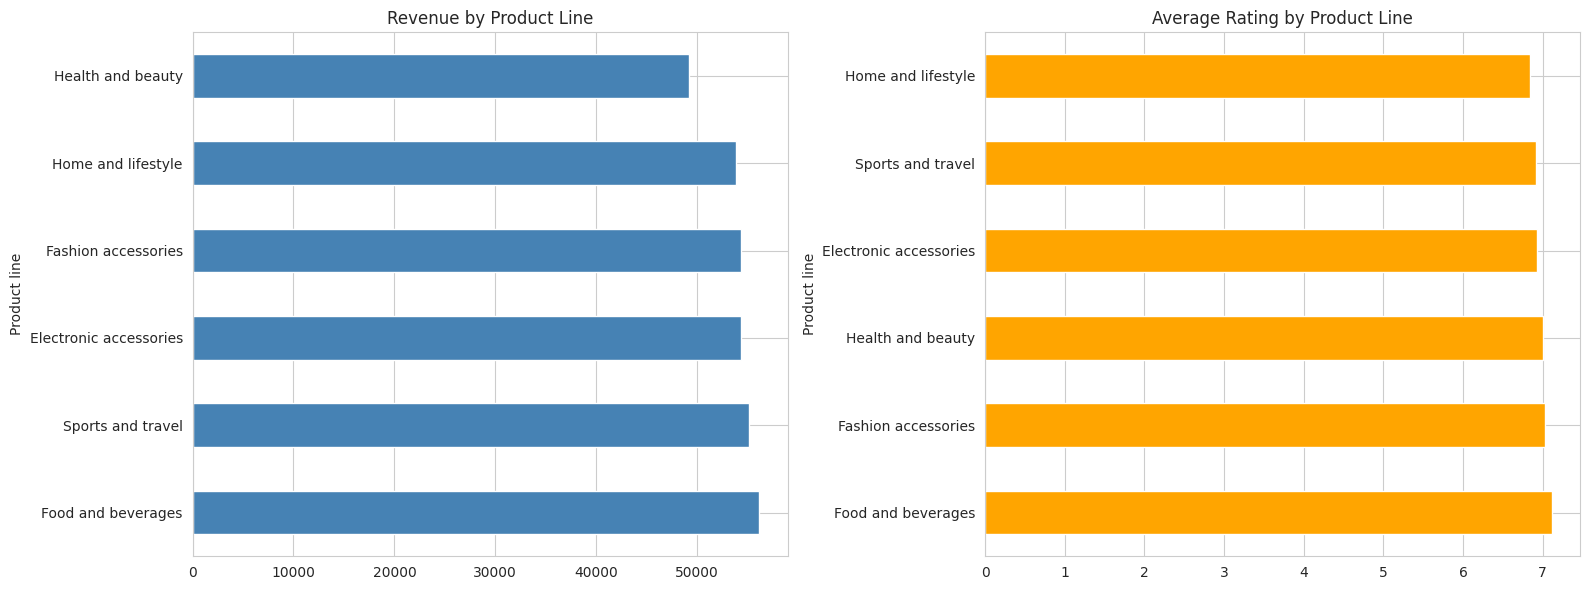

In [20]:
revenue_by_product = df.groupby("Product line")["Total"].sum().sort_values(ascending=False)
qty_by_product = df.groupby("Product line")["Quantity"].sum().sort_values(ascending=False)
rating_by_product = df.groupby("Product line")["Rating"].mean().sort_values(ascending=False)

print("Revenue by product line:\n", revenue_by_product)
print("\nQuantity sold by product line:\n", qty_by_product)
print("\nAverage rating by product line:\n", rating_by_product)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
revenue_by_product.plot(kind="barh", ax=axes[0], color="steelblue", title="Revenue by Product Line")
rating_by_product.plot(kind="barh", ax=axes[1], color="orange", title="Average Rating by Product Line")
plt.tight_layout()
plt.show()


Average spend by customer type:
 Customer type
Member    327.791305
Normal    318.122856
Name: Total, dtype: float64

Average spend by gender:
 Gender
Female    335.095659
Male      310.789226
Name: Total, dtype: float64

Transaction count by customer type:
 Customer type
Member    501
Normal    499
Name: count, dtype: int64


/tmp/ipykernel_2420/3341721759.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spend_by_customer_type.index, y=spend_by_customer_type.values, ax=axes[0], palette="Set2")


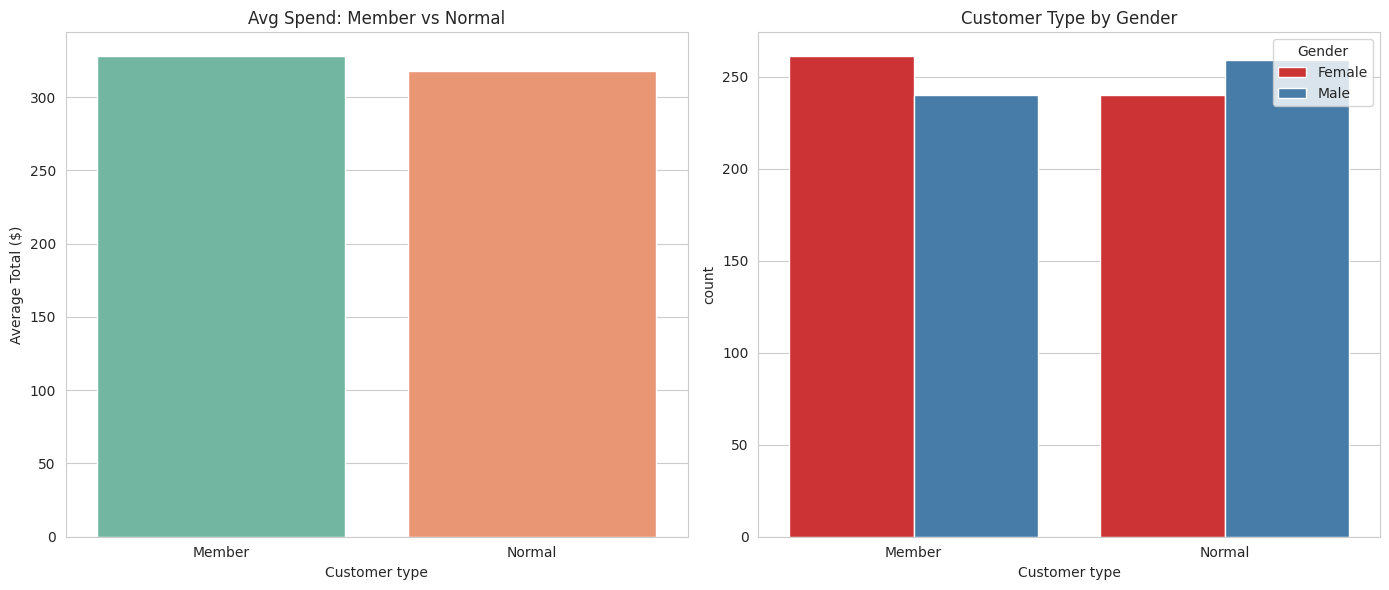

In [12]:
spend_by_customer_type = df.groupby("Customer type")["Total"].mean()
spend_by_gender = df.groupby("Gender")["Total"].mean()
count_by_customer_type = df["Customer type"].value_counts()

print("Average spend by customer type:\n", spend_by_customer_type)
print("\nAverage spend by gender:\n", spend_by_gender)
print("\nTransaction count by customer type:\n", count_by_customer_type)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=spend_by_customer_type.index, y=spend_by_customer_type.values, ax=axes[0], palette="Set2")
axes[0].set_title("Avg Spend: Member vs Normal")
axes[0].set_ylabel("Average Total ($)")

sns.countplot(data=df, x="Customer type", hue="Gender", ax=axes[1], palette="Set1")
axes[1].set_title("Customer Type by Gender")
plt.tight_layout()
plt.show()


Payment method usage:
 Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

Revenue by payment method:
 Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072
Name: Total, dtype: float64


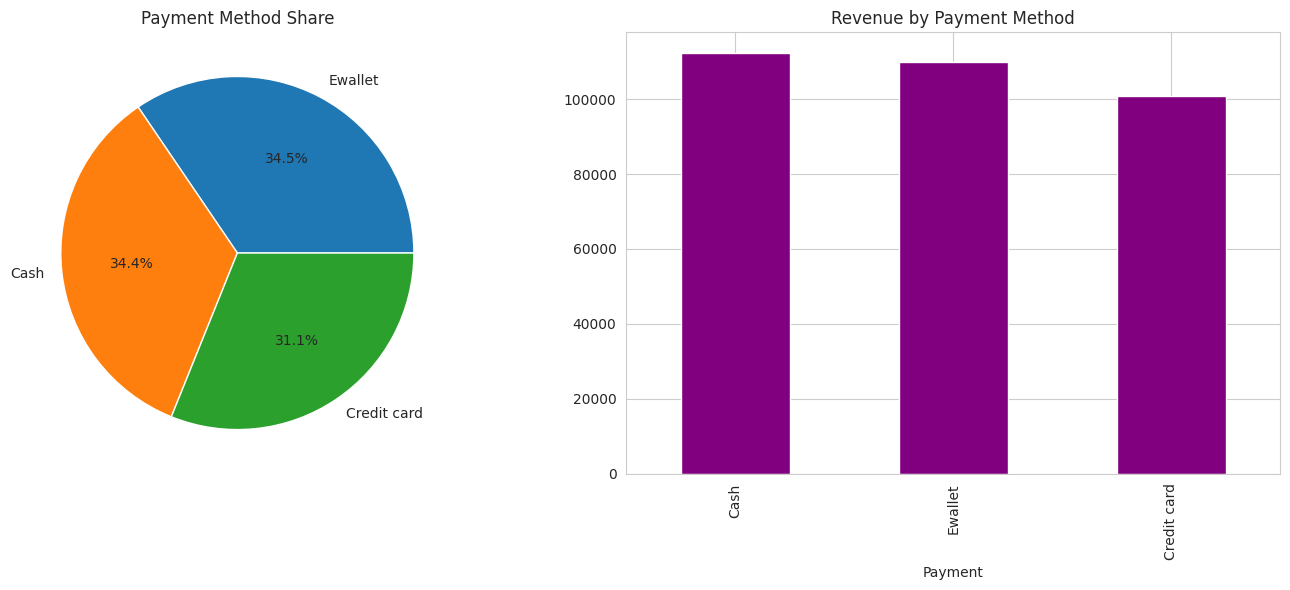

In [13]:
payment_counts = df["Payment"].value_counts()
revenue_by_payment = df.groupby("Payment")["Total"].sum().sort_values(ascending=False)

print("Payment method usage:\n", payment_counts)
print("\nRevenue by payment method:\n", revenue_by_payment)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
payment_counts.plot(kind="pie", autopct="%1.1f%%", ax=axes[0], title="Payment Method Share")
axes[0].set_ylabel("")
revenue_by_payment.plot(kind="bar", ax=axes[1], color="purple", title="Revenue by Payment Method")
plt.tight_layout()
plt.show()


Payment method usage:
 Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

Revenue by payment method:
 Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072
Name: Total, dtype: float64


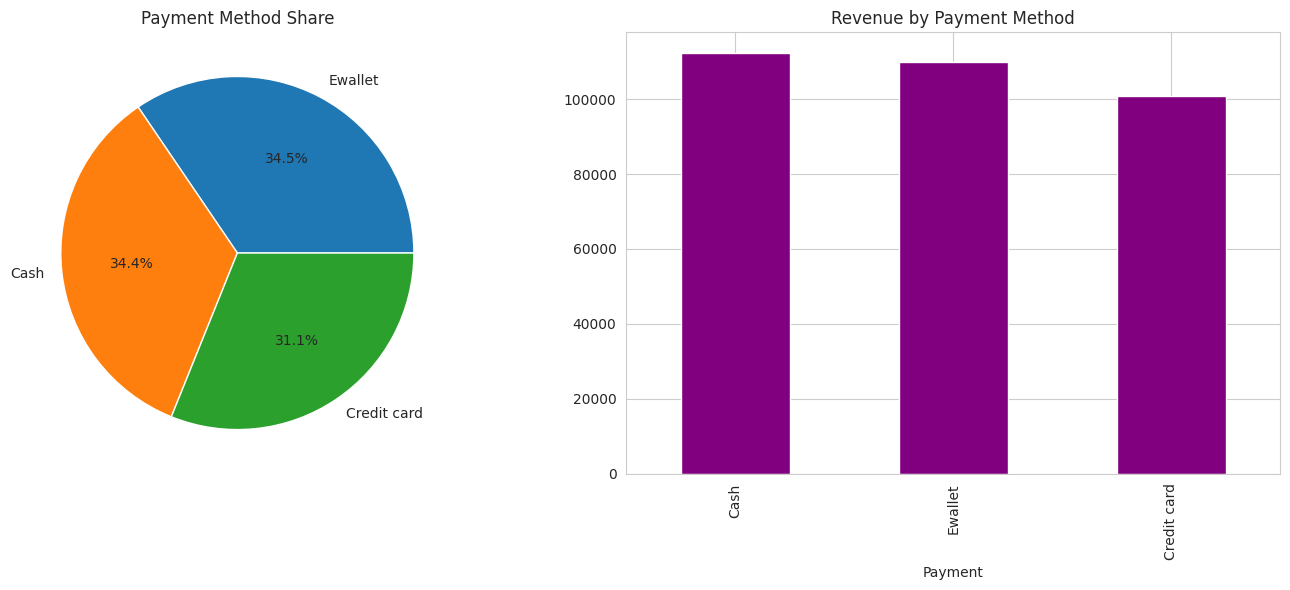

In [21]:
payment_counts = df["Payment"].value_counts()
revenue_by_payment = df.groupby("Payment")["Total"].sum().sort_values(ascending=False)

print("Payment method usage:\n", payment_counts)
print("\nRevenue by payment method:\n", revenue_by_payment)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
payment_counts.plot(kind="pie", autopct="%1.1f%%", ax=axes[0], title="Payment Method Share")
axes[0].set_ylabel("")
revenue_by_payment.plot(kind="bar", ax=axes[1], color="purple", title="Revenue by Payment Method")
plt.tight_layout()
plt.show()

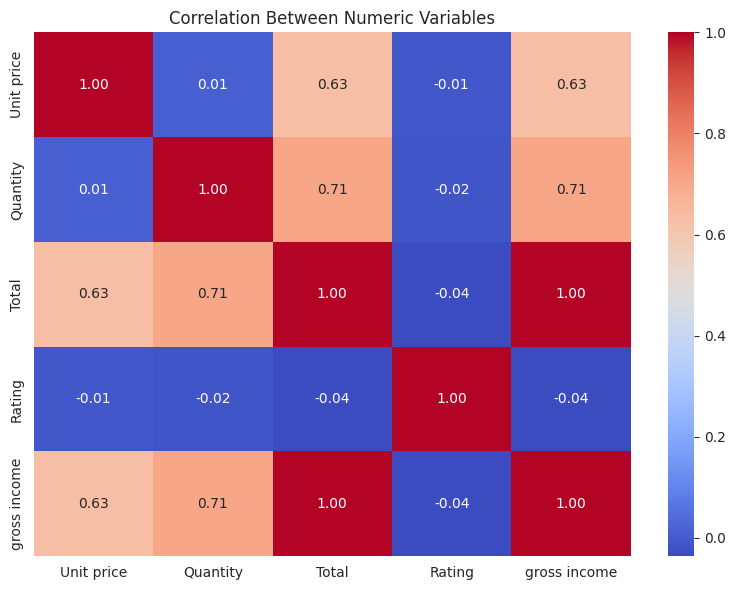

In [15]:
numeric_cols = ["Unit price", "Quantity", "Total", "Rating", "gross income"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numeric Variables")
plt.tight_layout()
plt.show()



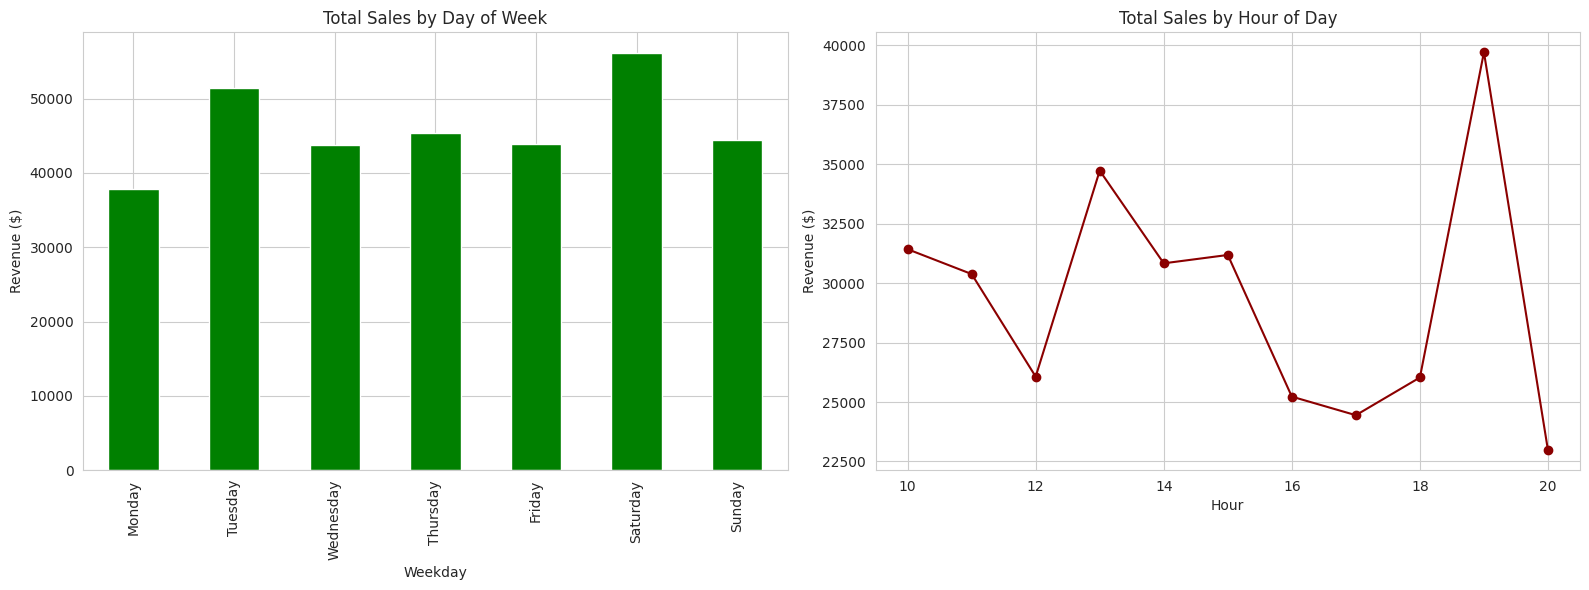

In [24]:
sales_by_weekday = df.groupby("Weekday")["Total"].sum()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_weekday = sales_by_weekday.reindex(weekday_order)

sales_by_hour = df.groupby("Hour")["Total"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sales_by_weekday.plot(kind="bar", ax=axes[0], color="green", title="Total Sales by Day of Week")
axes[0].set_ylabel("Revenue ($)")

sales_by_hour.plot(kind="line", marker="o", ax=axes[1], color="darkred", title="Total Sales by Hour of Day")
axes[1].set_ylabel("Revenue ($)")
axes[1].set_xlabel("Hour")
plt.tight_layout()
plt.show()


In [17]:
df.to_csv("supermarket_sales_cleaned.csv", index=False)
from google.colab import files as files2
files2.download("supermarket_sales_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>